# Advanced NLP Part 1 - Basics

## Course Overview

In this notebook, we will explore fundamental **Natural Language Processing (NLP)** techniques that form the backbone of many real-world text analysis systems. By the end of this session, you will understand:

| Topic | What You Will Learn |
|-------|--------------------|
| **POS Tagging** | How to identify the grammatical role of each word in a sentence |
| **Shallow Parsing** | How to group words into meaningful phrases (chunks) |
| **Dependency Parsing** | How to find grammatical relationships between words |
| **Named Entity Recognition** | How to identify people, places, organizations in text |
| **Topic Modeling** | How to discover hidden themes in large document collections |

### Why Do These Matter?

These techniques are used everywhere:
- **Search engines** use POS tagging and NER to understand your queries
- **Virtual assistants** (Siri, Alexa) use dependency parsing to understand commands
- **News aggregators** use topic modeling to group articles by theme
- **Social media platforms** use NER to detect trending people and places

---

## 1. Setup and Installation

First, let's install and import all the libraries we need. Run the cell below to get started.

In [1]:
# Suppress warnings for cleaner output
import warnings
warnings.simplefilter("ignore", category=DeprecationWarning)
warnings.filterwarnings('ignore')

# Core libraries
import pandas as pd
import numpy as np
import re

# NLP libraries
import spacy
import nltk

# Download required NLTK data
nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)
nltk.download('averaged_perceptron_tagger', quiet=True)
nltk.download('averaged_perceptron_tagger_eng', quiet=True)
nltk.download('treebank', quiet=True)
nltk.download('conll2000', quiet=True)

# Load SpaCy English model
nlp = spacy.load("en_core_web_sm")

print("All libraries loaded successfully!")

All libraries loaded successfully!


---

# Part 1: Parts of Speech (POS) Tagging

## What is POS Tagging?

**Parts of Speech (POS) tagging** is the process of assigning a grammatical label (noun, verb, adjective, etc.) to each word in a sentence.

### Why is it important?

Consider the word **"bank"**:
- *"I went to the **bank** to deposit money."* → **Noun** (a financial institution)
- *"The plane **banked** to the left."* → **Verb** (to tilt/turn)
- *"We sat on the river **bank**."* → **Noun** (the edge of a river)

POS tagging helps computers understand which meaning a word carries based on its grammatical role.

### Common POS Tags (Penn Treebank Standard)

| Tag | Meaning | Example |
|-----|---------|--------|
| NN | Noun, singular | *dog, city, music* |
| NNS | Noun, plural | *dogs, cities* |
| NNP | Proper noun, singular | *London, Google* |
| VB | Verb, base form | *run, eat, play* |
| VBZ | Verb, 3rd person singular present | *runs, eats* |
| VBD | Verb, past tense | *ran, ate* |
| VBG | Verb, gerund | *running, eating* |
| JJ | Adjective | *big, fast, beautiful* |
| RB | Adverb | *quickly, very, well* |
| DT | Determiner | *the, a, an* |
| IN | Preposition | *in, on, at, by* |
| PRP | Personal pronoun | *I, you, he, she* |
| CC | Coordinating conjunction | *and, but, or* |

## 2. POS Tagging with SpaCy

**SpaCy** is a modern, fast NLP library. It uses a neural network model to predict POS tags, making it very accurate.

Let's start with a simple example:

In [2]:
# Step 1: Define our sentence
sentence = "US unveils world's most powerful supercomputer, beats China."
print(f"Sentence: {sentence}")
print(f"Number of characters: {len(sentence)}")

Sentence: US unveils world's most powerful supercomputer, beats China.
Number of characters: 60


In [3]:
# Step 2: Process the sentence with SpaCy
# nlp() tokenizes the text and runs the full NLP pipeline (tokenization, POS, NER, etc.)
sentence_nlp = nlp(sentence)

# Let's see what SpaCy created - it splits the sentence into tokens
print("Tokens created by SpaCy:")
for i, token in enumerate(sentence_nlp):
    print(f"  Token {i}: '{token.text}'")

Tokens created by SpaCy:
  Token 0: 'US'
  Token 1: 'unveils'
  Token 2: 'world'
  Token 3: ''s'
  Token 4: 'most'
  Token 5: 'powerful'
  Token 6: 'supercomputer'
  Token 7: ','
  Token 8: 'beats'
  Token 9: 'China'
  Token 10: '.'


In [4]:
# Step 3: Extract POS tags for each word
# SpaCy provides two types of tags:
#   - token.tag_  : Fine-grained tag (e.g., NNP, VBZ) - Penn Treebank standard
#   - token.pos_  : Coarse-grained tag (e.g., NOUN, VERB) - Universal POS tags

spacy_pos_tagged = [(word.text, word.tag_, word.pos_) for word in sentence_nlp]

# Display as a nice table
df_pos = pd.DataFrame(spacy_pos_tagged, columns=['Word', 'Fine POS Tag', 'Coarse POS Tag'])
df_pos

,Word,Fine POS Tag,Coarse POS Tag
0,US,NNP,PROPN
1,unveils,VBZ,VERB
2,world,NN,NOUN
3,'s,POS,PART
4,most,RBS,ADV
5,powerful,JJ,ADJ
6,supercomputer,NN,NOUN
7,",",",",PUNCT
8,beats,VBZ,VERB
9,China,NNP,PROPN


In [5]:
# Step 4: Let's add explanations for each tag
# spacy.explain() gives a human-readable description of each tag

for word in sentence_nlp:
    print(f"'{word.text:20s}' -> {word.tag_:5s} ({spacy.explain(word.tag_)})")

'US                  ' -> NNP   (noun, proper singular)
'unveils             ' -> VBZ   (verb, 3rd person singular present)
'world               ' -> NN    (noun, singular or mass)
''s                  ' -> POS   (possessive ending)
'most                ' -> RBS   (adverb, superlative)
'powerful            ' -> JJ    (adjective (English), other noun-modifier (Chinese))
'supercomputer       ' -> NN    (noun, singular or mass)
',                   ' -> ,     (punctuation mark, comma)
'beats               ' -> VBZ   (verb, 3rd person singular present)
'China               ' -> NNP   (noun, proper singular)
'.                   ' -> .     (punctuation mark, sentence closer)


### Let's Try More Examples with SpaCy

In [6]:
# Example 2: A more complex sentence
example_sentences = [
    "The quick brown fox jumps over the lazy dog.",
    "She quickly finished her homework before dinner.",
    "Running is a great exercise for building stamina.",
    "Nigeria is the most populous country in Africa."
]

for sent in example_sentences:
    doc = nlp(sent)
    print(f"\nSentence: {sent}")
    print("-" * 60)
    for token in doc:
        print(f"  {token.text:15s} -> {token.pos_:8s} ({spacy.explain(token.pos_)})")


Sentence: The quick brown fox jumps over the lazy dog.
------------------------------------------------------------
  The             -> DET      (determiner)
  quick           -> ADJ      (adjective)
  brown           -> ADJ      (adjective)
  fox             -> NOUN     (noun)
  jumps           -> VERB     (verb)
  over            -> ADP      (adposition)
  the             -> DET      (determiner)
  lazy            -> ADJ      (adjective)
  dog             -> NOUN     (noun)
  .               -> PUNCT    (punctuation)

Sentence: She quickly finished her homework before dinner.
------------------------------------------------------------
  She             -> PRON     (pronoun)
  quickly         -> ADV      (adverb)
  finished        -> VERB     (verb)
  her             -> PRON     (pronoun)
  homework        -> NOUN     (noun)
  before          -> ADP      (adposition)
  dinner          -> NOUN     (noun)
  .               -> PUNCT    (punctuation)

Sentence: Running is a great exerc

---

### Practice Exercise 1

**Task:** Write code to POS-tag the following sentence using SpaCy and display the results in a DataFrame.

Sentence: `"The students are learning natural language processing in their advanced AI course."`

**Bonus:** Count how many nouns, verbs, and adjectives are in the sentence.

In [7]:
# YOUR CODE HERE
# Step 1: Define the sentence
practice_sentence = "The students are learning natural language processing in their advanced AI course."

# Step 2: Process with SpaCy
# practice_doc = nlp(___)

# Step 3: Create a list of (word, fine_tag, coarse_tag) tuples
# pos_data = [(token.text, ___, ___) for token in ___]

# Step 4: Display as DataFrame
# pd.DataFrame(pos_data, columns=['Word', 'Fine Tag', 'Coarse Tag'])

# Bonus: Count POS categories
# from collections import Counter
# pos_counts = Counter([token.pos_ for token in practice_doc])
# print(pos_counts)

<details>
<summary>Click to see the solution</summary>

```python
practice_sentence = "The students are learning natural language processing in their advanced AI course."
practice_doc = nlp(practice_sentence)
pos_data = [(token.text, token.tag_, token.pos_) for token in practice_doc]
display(pd.DataFrame(pos_data, columns=['Word', 'Fine Tag', 'Coarse Tag']))

from collections import Counter
pos_counts = Counter([token.pos_ for token in practice_doc])
print("\nPOS Counts:", dict(pos_counts))
```
</details>

---

## 3. POS Tagging with NLTK

**NLTK** (Natural Language Toolkit) is one of the oldest and most widely-used NLP libraries. It uses the **Penn Treebank** tag set.

### Key Difference: SpaCy vs NLTK
- **SpaCy** processes text through a complete pipeline in one step
- **NLTK** requires you to tokenize first, then tag separately

```
SpaCy:  sentence → nlp(sentence) → tokens with POS tags
NLTK:   sentence → word_tokenize(sentence) → pos_tag(tokens) → tagged tokens
```

In [8]:
# POS Tagging with NLTK

# Step 1: Tokenize the sentence (split into words)
tokens = nltk.word_tokenize(sentence)
print("Step 1 - Tokens:", tokens)

# Step 2: Apply POS tagging to the tokens
nltk_pos_tagged = nltk.pos_tag(tokens)
print("\nStep 2 - POS Tagged:", nltk_pos_tagged)

# Step 3: Display as a table
pd.DataFrame(nltk_pos_tagged, columns=['Word', 'POS Tag'])

Step 1 - Tokens: ['US', 'unveils', 'world', "'s", 'most', 'powerful', 'supercomputer', ',', 'beats', 'China', '.']

Step 2 - POS Tagged: [('US', 'NNP'), ('unveils', 'JJ'), ('world', 'NN'), ("'s", 'POS'), ('most', 'RBS'), ('powerful', 'JJ'), ('supercomputer', 'NN'), (',', ','), ('beats', 'VBZ'), ('China', 'NNP'), ('.', '.')]


,Word,POS Tag
0,US,NNP
1,unveils,JJ
2,world,NN
3,'s,POS
4,most,RBS
5,powerful,JJ
6,supercomputer,NN
7,",",","
8,beats,VBZ
9,China,NNP


### Comparing SpaCy vs NLTK Results

Let's compare how both libraries tag the same sentence. Notice any differences?

In [9]:
# Side-by-side comparison
comparison = []
spacy_doc = nlp(sentence)
nltk_tagged = nltk.pos_tag(nltk.word_tokenize(sentence))

print(f"{'Word':<20} {'SpaCy Tag':<12} {'NLTK Tag':<12} {'Match?'}")
print("-" * 56)
for spacy_token, (nltk_word, nltk_tag) in zip(spacy_doc, nltk_tagged):
    match = "Yes" if spacy_token.tag_ == nltk_tag else "NO"
    print(f"{spacy_token.text:<20} {spacy_token.tag_:<12} {nltk_tag:<12} {match}")

Word                 SpaCy Tag    NLTK Tag     Match?
--------------------------------------------------------
US                   NNP          NNP          Yes
unveils              VBZ          JJ           NO
world                NN           NN           Yes
's                   POS          POS          Yes
most                 RBS          RBS          Yes
powerful             JJ           JJ           Yes
supercomputer        NN           NN           Yes
,                    ,            ,            Yes
beats                VBZ          VBZ          Yes
China                NNP          NNP          Yes
.                    .            .            Yes


> **Key Takeaway:** SpaCy and NLTK may produce different tags for the same words. This is because they use different models and algorithms. SpaCy typically uses neural networks while NLTK uses statistical methods. Neither is always "correct" - context matters!

---

## 4. Building POS Taggers from Scratch

Now let's understand **how POS taggers work internally** by building several taggers of increasing complexity.

We'll use the **Penn Treebank** corpus - a large collection of text that has been manually tagged by linguists.

### Loading and Splitting the Data

In [10]:
from nltk.corpus import treebank

# Load the pre-tagged sentences
data = treebank.tagged_sents()

# Split into training and test sets
# The model learns from training data and is evaluated on test data
train_data = data[:3500]  # 3500 sentences for training
test_data = data[3500:]   # remaining sentences for testing

print(f"Total sentences: {len(data)}")
print(f"Training sentences: {len(train_data)}")
print(f"Test sentences: {len(test_data)}")
print(f"\nSample tagged sentence:")
print(train_data[0])

Total sentences: 3914
Training sentences: 3500
Test sentences: 414

Sample tagged sentence:
[('Pierre', 'NNP'), ('Vinken', 'NNP'), (',', ','), ('61', 'CD'), ('years', 'NNS'), ('old', 'JJ'), (',', ','), ('will', 'MD'), ('join', 'VB'), ('the', 'DT'), ('board', 'NN'), ('as', 'IN'), ('a', 'DT'), ('nonexecutive', 'JJ'), ('director', 'NN'), ('Nov.', 'NNP'), ('29', 'CD'), ('.', '.')]


### 4.1 Default Tagger (Baseline)

The simplest possible tagger: assign the **same tag to every word**.

Since nouns (NN) are the most common POS, let's tag everything as a noun and see how accurate that is.

In [11]:
from nltk.tag import DefaultTagger

# Create a tagger that labels EVERY word as a noun (NN)
dt = DefaultTagger('NN')

# Test accuracy on test data
accuracy = dt.evaluate(test_data)
print(f"Default Tagger Accuracy: {accuracy:.2%}")
print(f"\nThis means only {accuracy:.2%} of words in English are nouns!")

# Let's see what it does to our sentence
print(f"\nTagged sentence:")
print(dt.tag(nltk.word_tokenize(sentence)))

Default Tagger Accuracy: 14.54%

This means only 14.54% of words in English are nouns!

Tagged sentence:
[('US', 'NN'), ('unveils', 'NN'), ('world', 'NN'), ("'s", 'NN'), ('most', 'NN'), ('powerful', 'NN'), ('supercomputer', 'NN'), (',', 'NN'), ('beats', 'NN'), ('China', 'NN'), ('.', 'NN')]


> **Observation:** The default tagger gets about 14.5% accuracy. This is our baseline - any smarter tagger should do better!

### 4.2 Regex Tagger (Pattern-Based)

A **regex tagger** uses word endings (suffixes) to guess the POS tag.

For example:
- Words ending in **-ing** are often verbs (running, eating)
- Words ending in **-ed** are often past tense verbs (walked, played)
- Words ending in **-s** are often plural nouns (dogs, cats)

In [12]:
from nltk.tag import RegexpTagger

# Define regex patterns: (pattern, tag)
# The tagger checks patterns from top to bottom and uses the first match
patterns = [
    (r'.*ing$', 'VBG'),               # words ending in -ing → gerunds (running)
    (r'.*ed$', 'VBD'),                 # words ending in -ed → past tense (walked)
    (r'.*es$', 'VBZ'),                 # words ending in -es → 3rd person singular (goes)
    (r'.*ould$', 'MD'),                # words ending in -ould → modals (would, could)
    (r'.*\'s$', 'NN$'),               # words ending in 's → possessive nouns
    (r'.*s$', 'NNS'),                  # words ending in -s → plural nouns (dogs)
    (r'^-?[0-9]+(.[0-9]+)?$', 'CD'),   # numbers → cardinal numbers (42, 3.14)
    (r'.*', 'NN')                      # everything else → default to noun
]

rt = RegexpTagger(patterns)

# Test accuracy
accuracy = rt.evaluate(test_data)
print(f"Regex Tagger Accuracy: {accuracy:.2%}")
print(f"\nTagged sentence:")
print(rt.tag(nltk.word_tokenize(sentence)))

Regex Tagger Accuracy: 24.04%

Tagged sentence:
[('US', 'NN'), ('unveils', 'NNS'), ('world', 'NN'), ("'s", 'NN$'), ('most', 'NN'), ('powerful', 'NN'), ('supercomputer', 'NN'), (',', 'NN'), ('beats', 'NNS'), ('China', 'NN'), ('.', 'NN')]


> **Observation:** The regex tagger improved to ~24% accuracy. Still not great, but better than random guessing. The problem? Many words don't follow simple suffix patterns.

### 4.3 N-Gram Taggers (Learning from Data)

**N-gram taggers** learn from the training data by memorizing which tags appear with which words.

- **Unigram tagger:** Looks at each word individually and assigns its most common tag from training
- **Bigram tagger:** Considers the previous word's tag + current word
- **Trigram tagger:** Considers the two previous tags + current word

Think of it like this:
```
Unigram: What tag does "bank" usually have?     → NN (noun)
Bigram:  After a DT tag, what tag does "bank" have?  → NN (noun) ("the bank")
Trigram: After DT + JJ tags, what tag does "bank" have? → NN (noun) ("the big bank")
```

In [13]:
from nltk.tag import UnigramTagger, BigramTagger, TrigramTagger

# Train each tagger on the training data
ut = UnigramTagger(train_data)
bt = BigramTagger(train_data)
tt = TrigramTagger(train_data)

# Compare their accuracies
print("Tagger Comparison:")
print(f"  Unigram Tagger: {ut.evaluate(test_data):.2%}")
print(f"  Bigram Tagger:  {bt.evaluate(test_data):.2%}")
print(f"  Trigram Tagger: {tt.evaluate(test_data):.2%}")

Tagger Comparison:
  Unigram Tagger: 86.08%
  Bigram Tagger:  13.47%
  Trigram Tagger: 8.06%


In [14]:
# Let's see WHY bigram and trigram taggers do so poorly
print("Unigram tagger output:")
print(ut.tag(nltk.word_tokenize(sentence)))

print("\nBigram tagger output:")
print(bt.tag(nltk.word_tokenize(sentence)))

print("\nTrigram tagger output:")
print(tt.tag(nltk.word_tokenize(sentence)))

Unigram tagger output:
[('US', 'NNP'), ('unveils', None), ('world', 'NN'), ("'s", 'POS'), ('most', 'JJS'), ('powerful', 'JJ'), ('supercomputer', 'NN'), (',', ','), ('beats', None), ('China', 'NNP'), ('.', '.')]

Bigram tagger output:
[('US', None), ('unveils', None), ('world', None), ("'s", None), ('most', None), ('powerful', None), ('supercomputer', None), (',', None), ('beats', None), ('China', None), ('.', None)]

Trigram tagger output:
[('US', None), ('unveils', None), ('world', None), ("'s", None), ('most', None), ('powerful', None), ('supercomputer', None), (',', None), ('beats', None), ('China', None), ('.', None)]


> **Why do bigram/trigram taggers perform worse?**
> 
> They suffer from the **data sparsity problem**: they need to have seen the exact sequence of words/tags during training. If they encounter an unseen combination, they return `None`. The more context they require, the less likely they are to find a match.
>
> Notice how the bigram and trigram taggers return `None` for almost every word in our sentence!

### 4.4 Combined Tagger with Backoff (Best of All Worlds)

The solution is to **chain taggers together** using a **backoff strategy**:

1. Try the trigram tagger first (most context, most accurate when it works)
2. If it fails, fall back to the bigram tagger
3. If that fails, fall back to the unigram tagger  
4. If that fails, fall back to the regex tagger

In [15]:
def combined_tagger(train_data, taggers, backoff=None):
    """Build a chain of taggers, each backing off to the next."""
    for tagger in taggers:
        backoff = tagger(train_data, backoff=backoff)
    return backoff

# Build the combined tagger: Unigram -> Bigram -> Trigram, with regex as final backoff
ct = combined_tagger(
    train_data=train_data, 
    taggers=[UnigramTagger, BigramTagger, TrigramTagger],
    backoff=rt  # regex tagger as the last resort
)

# Evaluate
accuracy = ct.evaluate(test_data)
print(f"Combined Tagger Accuracy: {accuracy:.2%}")
print(f"\nTagged sentence:")
print(ct.tag(nltk.word_tokenize(sentence)))

Combined Tagger Accuracy: 90.95%

Tagged sentence:
[('US', 'NNP'), ('unveils', 'NNS'), ('world', 'NN'), ("'s", 'POS'), ('most', 'RBS'), ('powerful', 'JJ'), ('supercomputer', 'NN'), (',', ','), ('beats', 'NNS'), ('China', 'NNP'), ('.', '.')]


> **Result:** The combined tagger achieves ~91% accuracy! Much better than any individual tagger.

### 4.5 Classifier-Based Tagger (Machine Learning Approach)

The most sophisticated approach uses a **machine learning classifier** (Naive Bayes) that considers multiple features of each word:
- The word itself
- Word suffixes and prefixes
- Previous word and its tag
- Whether the word is capitalized

In [16]:
from nltk.classify import NaiveBayesClassifier
from nltk.tag.sequential import ClassifierBasedPOSTagger

# Train a Naive Bayes classifier-based POS tagger
# Note: This takes a bit longer because it's training a real ML model
nbt = ClassifierBasedPOSTagger(
    train=train_data,
    classifier_builder=NaiveBayesClassifier.train
)

# Evaluate
accuracy = nbt.evaluate(test_data)
print(f"Naive Bayes Tagger Accuracy: {accuracy:.2%}")
print(f"\nTagged sentence:")
print(nbt.tag(nltk.word_tokenize(sentence)))

Naive Bayes Tagger Accuracy: 93.07%

Tagged sentence:
[('US', 'PRP'), ('unveils', 'VBZ'), ('world', 'VBN'), ("'s", 'POS'), ('most', 'JJS'), ('powerful', 'JJ'), ('supercomputer', 'NN'), (',', ','), ('beats', 'VBZ'), ('China', 'NNP'), ('.', '.')]


### Summary: POS Tagger Comparison

Let's visualize how all our taggers compare:

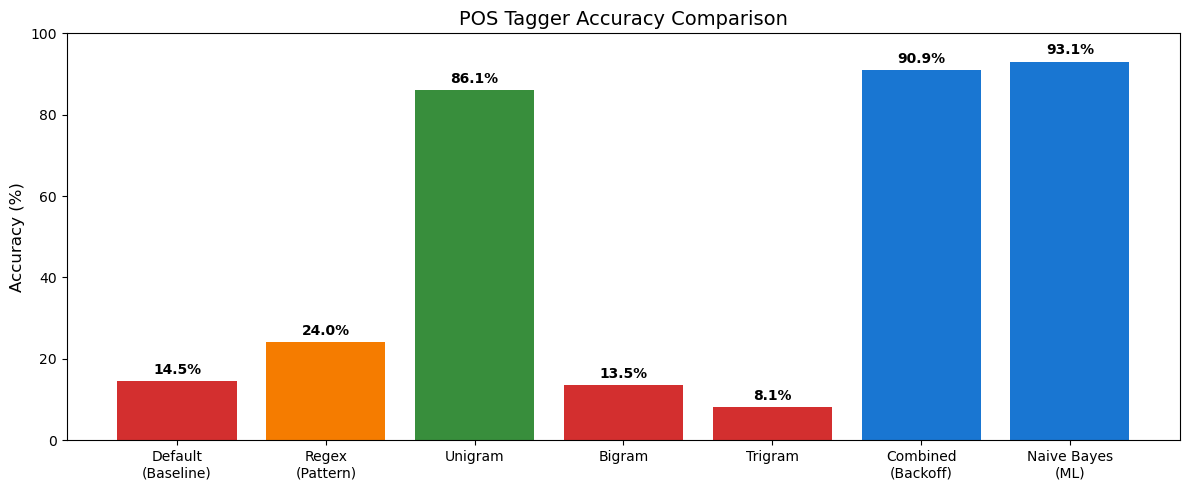

In [17]:
import matplotlib.pyplot as plt

taggers = {
    'Default\n(Baseline)': dt.evaluate(test_data),
    'Regex\n(Pattern)': rt.evaluate(test_data),
    'Unigram': ut.evaluate(test_data),
    'Bigram': bt.evaluate(test_data),
    'Trigram': tt.evaluate(test_data),
    'Combined\n(Backoff)': ct.evaluate(test_data),
    'Naive Bayes\n(ML)': nbt.evaluate(test_data),
}

fig, ax = plt.subplots(figsize=(12, 5))
colors = ['#d32f2f', '#f57c00', '#388e3c', '#d32f2f', '#d32f2f', '#1976d2', '#1976d2']
bars = ax.bar(taggers.keys(), [v * 100 for v in taggers.values()], color=colors)
ax.set_ylabel('Accuracy (%)', fontsize=12)
ax.set_title('POS Tagger Accuracy Comparison', fontsize=14)
ax.set_ylim(0, 100)

# Add value labels on bars
for bar, val in zip(bars, taggers.values()):
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 1,
            f'{val:.1%}', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

---

### Practice Exercise 2

**Task:** Create a custom regex tagger that can identify:
- Words ending in **-ly** as adverbs (RB)
- Words ending in **-tion** or **-sion** as nouns (NN)
- Words ending in **-able** or **-ible** as adjectives (JJ)
- Keep all the existing patterns too

Test it on: `"The incredibly responsible organization made a reasonable decision quickly."`

In [18]:
# YOUR CODE HERE
# Hint: Add new patterns BEFORE the existing ones (order matters!)

# improved_patterns = [
#     (r'.*ly$', '___'),        # adverbs ending in -ly
#     (r'.*tion$', '___'),      # nouns ending in -tion
#     (r'.*sion$', '___'),      # nouns ending in -sion
#     (r'.*able$', '___'),      # adjectives ending in -able
#     (r'.*ible$', '___'),      # adjectives ending in -ible
#     ... existing patterns ...
# ]
# improved_rt = RegexpTagger(improved_patterns)
# test_sent = "The incredibly responsible organization made a reasonable decision quickly."
# print(improved_rt.tag(nltk.word_tokenize(test_sent)))

<details>
<summary>Click to see the solution</summary>

```python
improved_patterns = [
    (r'.*ly$', 'RB'),              # adverbs ending in -ly
    (r'.*tion$', 'NN'),            # nouns ending in -tion
    (r'.*sion$', 'NN'),            # nouns ending in -sion
    (r'.*able$', 'JJ'),            # adjectives ending in -able
    (r'.*ible$', 'JJ'),            # adjectives ending in -ible
    (r'.*ing$', 'VBG'),
    (r'.*ed$', 'VBD'),
    (r'.*es$', 'VBZ'),
    (r'.*ould$', 'MD'),
    (r'.*\'s$', 'NN$'),
    (r'.*s$', 'NNS'),
    (r'^-?[0-9]+(.[0-9]+)?$', 'CD'),
    (r'.*', 'NN')
]
improved_rt = RegexpTagger(improved_patterns)
test_sent = "The incredibly responsible organization made a reasonable decision quickly."
print(improved_rt.tag(nltk.word_tokenize(test_sent)))
print(f"\nAccuracy: {improved_rt.evaluate(test_data):.2%}")
```
</details>

---

# Part 2: Shallow Parsing (Chunking)

## What is Shallow Parsing?

**Shallow parsing** (also called **chunking**) groups consecutive words into meaningful phrases based on their POS tags.

For example:
```
Input:  "The quick brown fox jumps over the lazy dog"
Output: [The quick brown fox]NP [jumps]VP [over]PP [the lazy dog]NP
```

### Types of Chunks
| Chunk | Name | Example |
|-------|------|---------|
| **NP** | Noun Phrase | *the big dog*, *a beautiful sunset* |
| **VP** | Verb Phrase | *is running*, *has been eating* |
| **PP** | Prepositional Phrase | *in the park*, *on the table* |
| **ADJP** | Adjective Phrase | *very tall*, *extremely happy* |
| **ADVP** | Adverb Phrase | *very quickly*, *so well* |

### Chunking vs Chinking
- **Chunking**: Define what TO include in a chunk
- **Chinking**: Start with everything as one chunk, then define what to EXCLUDE

## 5. Regex-Based Chunking

### 5.1 Basic NP Chunking

The most common task is extracting **Noun Phrases (NP)**. A simple NP pattern is:

```
NP: {<DT>?<JJ>*<NN.*>}
```

This reads: "An NP is an optional determiner, followed by zero or more adjectives, followed by a noun."

In [19]:
from nltk.chunk import RegexpParser

# Step 1: Get POS tags for our sentence
tagged_sent = nltk.pos_tag(nltk.word_tokenize(sentence))
print("POS Tags:", tagged_sent)

POS Tags: [('US', 'NNP'), ('unveils', 'JJ'), ('world', 'NN'), ("'s", 'POS'), ('most', 'RBS'), ('powerful', 'JJ'), ('supercomputer', 'NN'), (',', ','), ('beats', 'VBZ'), ('China', 'NNP'), ('.', '.')]


In [20]:
# Step 2: Define a chunk grammar
# The grammar uses regex over POS tags (not words)
# {<DT>?<JJ>*<NN.*>} means:
#   <DT>?   = optional Determiner (the, a, an)
#   <JJ>*   = zero or more Adjectives
#   <NN.*>  = any Noun tag (NN, NNP, NNS, etc.)

chunk_grammar = """
NP: {<DT>?<JJ>*<NN.*>}
"""

# Step 3: Create the parser and parse
chunker = RegexpParser(chunk_grammar)
tree = chunker.parse(tagged_sent)

# Step 4: Display the result
print("Chunked sentence:")
print(tree)

Chunked sentence:
(S
  (NP US/NNP)
  (NP unveils/JJ world/NN)
  's/POS
  most/RBS
  (NP powerful/JJ supercomputer/NN)
  ,/,
  beats/VBZ
  (NP China/NNP)
  ./.)


### 5.2 Understanding Chunk Grammar Syntax

Let's break down the grammar notation:

| Symbol | Meaning | Example |
|--------|---------|--------|
| `{...}` | Define what's INSIDE a chunk | `{<NN>}` = nouns are chunks |
| `}...{` | Define what's OUTSIDE a chunk (chinking) | `}<VB>{` = verbs break chunks |
| `<TAG>` | Match a POS tag | `<NN>` matches nouns |
| `<TAG>?` | Optional (0 or 1) | `<DT>?` = optional determiner |
| `<TAG>*` | Zero or more | `<JJ>*` = any number of adjectives |
| `<TAG>+` | One or more | `<NN>+` = at least one noun |
| `<TAG1\|TAG2>` | Either tag | `<NN\|NNP>` = noun or proper noun |

In [21]:
# Let's try a more complete grammar that identifies multiple phrase types
full_grammar = """
NP: {<DT>?<JJ>?<NN.*>}  
ADJP: {<JJ>}
ADVP: {<RB.*>}
PP: {<IN>}      
VP: {<MD>?<VB.*>+}
"""

full_chunker = RegexpParser(full_grammar)
tree = full_chunker.parse(tagged_sent)
print("Full shallow parse:")
print(tree)

Full shallow parse:
(S
  (NP US/NNP)
  (NP unveils/JJ world/NN)
  's/POS
  (ADVP most/RBS)
  (NP powerful/JJ supercomputer/NN)
  ,/,
  (VP beats/VBZ)
  (NP China/NNP)
  ./.)


In [22]:
# Let's try chunking on a new example to see it more clearly
example = "The tall professor gave an interesting lecture in the large auditorium."
tagged_example = nltk.pos_tag(nltk.word_tokenize(example))
print("POS Tags:", tagged_example)
print("\nChunked:")
print(full_chunker.parse(tagged_example))

POS Tags: [('The', 'DT'), ('tall', 'NN'), ('professor', 'NN'), ('gave', 'VBD'), ('an', 'DT'), ('interesting', 'JJ'), ('lecture', 'NN'), ('in', 'IN'), ('the', 'DT'), ('large', 'JJ'), ('auditorium', 'NN'), ('.', '.')]

Chunked:
(S
  (NP The/DT tall/NN)
  (NP professor/NN)
  (VP gave/VBD)
  (NP an/DT interesting/JJ lecture/NN)
  (PP in/IN)
  (NP the/DT large/JJ auditorium/NN)
  ./.)


### 5.3 Chinking (Inverse of Chunking)

Instead of defining what goes INTO a chunk, we can define what to REMOVE from chunks.

The `}...{` notation defines a **chink** (a gap in the chunk).

In [23]:
# Chinking: Start with everything as one chunk, then remove verbs
chink_grammar = """
NP:
    {<.*>+}             # First, chunk EVERYTHING as NP
    }<VBZ|VBD|JJ|IN>+{  # Then, remove (chink) sequences of verbs, adjectives, prepositions
"""

chink_chunker = RegexpParser(chink_grammar)
tree = chink_chunker.parse(tagged_sent)
print("Chinking result:")
print(tree)

Chinking result:
(S
  (NP US/NNP)
  unveils/JJ
  (NP world/NN 's/POS most/RBS)
  powerful/JJ
  (NP supercomputer/NN ,/,)
  beats/VBZ
  (NP China/NNP ./.))


---

### Practice Exercise 3

**Task:** Write a chunk grammar that can extract:
1. Noun phrases (NP): determiner + adjectives + noun(s)
2. Verb phrases (VP): modal + verb(s)

Test it on: `"The smart students should carefully review their difficult homework assignments."`

In [24]:
# YOUR CODE HERE
test_sentence = "The smart students should carefully review their difficult homework assignments."

# Step 1: POS tag the sentence
# tagged = nltk.pos_tag(nltk.word_tokenize(test_sentence))

# Step 2: Define your chunk grammar
# my_grammar = """
# NP: {___}
# VP: {___}
# """

# Step 3: Parse and display
# parser = RegexpParser(my_grammar)
# result = parser.parse(tagged)
# print(result)

<details>
<summary>Click to see the solution</summary>

```python
test_sentence = "The smart students should carefully review their difficult homework assignments."
tagged = nltk.pos_tag(nltk.word_tokenize(test_sentence))
print("POS Tags:", tagged)

my_grammar = """
NP: {<DT|PRP\$>?<JJ>*<NN.*>+}
VP: {<MD>?<RB>*<VB.*>+}
"""
parser = RegexpParser(my_grammar)
result = parser.parse(tagged)
print(result)
```
</details>

---

## 6. Training a Data-Driven Chunker

Instead of writing grammar rules by hand, we can **train a chunker from annotated data**.

### Understanding IOB Tagging

Chunked data uses **IOB notation** (Inside, Outside, Beginning):
- **B-NP**: Beginning of a noun phrase
- **I-NP**: Inside (continuation of) a noun phrase
- **O**: Outside any chunk

Example:
```
The     DT   B-NP   (beginning of NP)
big     JJ   I-NP   (inside NP)
dog     NN   I-NP   (inside NP)
runs    VBZ  O      (not in any chunk)
fast    RB   O      (not in any chunk)
```

In [25]:
from nltk.corpus import treebank_chunk
from nltk.chunk.util import tree2conlltags, conlltags2tree

# Load chunked data
chunk_data = treebank_chunk.chunked_sents()
train_chunk_data = chunk_data[:3500]
test_chunk_data = chunk_data[3500:]

# Look at a sample chunked sentence
sample = train_chunk_data[7]
print("Chunked tree format:")
print(sample)

# Convert to IOB format
print("\nIOB format (Word, POS, Chunk):")
iob_tags = tree2conlltags(sample)
for word, pos, chunk in iob_tags:
    print(f"  {word:15s} {pos:5s} {chunk}")

Chunked tree format:
(S
  (NP A/DT Lorillard/NNP spokewoman/NN)
  said/VBD
  ,/,
  ``/``
  (NP This/DT)
  is/VBZ
  (NP an/DT old/JJ story/NN)
  ./.)

IOB format (Word, POS, Chunk):
  A               DT    B-NP
  Lorillard       NNP   I-NP
  spokewoman      NN    I-NP
  said            VBD   O
  ,               ,     O
  ``              ``    O
  This            DT    B-NP
  is              VBZ   O
  an              DT    B-NP
  old             JJ    I-NP
  story           NN    I-NP
  .               .     O


In [26]:
# Now let's build an N-gram based chunker
# This chunker learns which POS tag sequences form chunks

from nltk.tag import UnigramTagger, BigramTagger
from nltk.chunk import ChunkParserI

def conll_tag_chunks(chunk_sents):
    """Convert chunked sentences to (POS_tag, chunk_tag) format."""
    tagged_sents = [tree2conlltags(tree) for tree in chunk_sents]
    return [[(t, c) for (w, t, c) in sent] for sent in tagged_sents]

def combined_tagger(train_data, taggers, backoff=None):
    """Chain taggers with backoff."""
    for tagger in taggers:
        backoff = tagger(train_data, backoff=backoff)
    return backoff

class NGramTagChunker(ChunkParserI):
    """A chunker that uses N-gram taggers to predict chunk tags from POS tags."""
    
    def __init__(self, train_sentences, tagger_classes=[UnigramTagger, BigramTagger]):
        train_sent_tags = conll_tag_chunks(train_sentences)
        self.chunk_tagger = combined_tagger(train_sent_tags, tagger_classes)

    def parse(self, tagged_sentence):
        if not tagged_sentence:
            return None
        pos_tags = [tag for word, tag in tagged_sentence]
        chunk_pos_tags = self.chunk_tagger.tag(pos_tags)
        chunk_tags = [chunk_tag for (pos_tag, chunk_tag) in chunk_pos_tags]
        wpc_tags = [(word, pos_tag, chunk_tag) 
                    for ((word, pos_tag), chunk_tag)
                    in zip(tagged_sentence, chunk_tags)]
        return conlltags2tree(wpc_tags)

In [27]:
# Train the chunker on treebank data
ntc = NGramTagChunker(train_chunk_data)

# Evaluate on test data
print("Trained Chunker Performance:")
print(ntc.evaluate(test_chunk_data))

Trained Chunker Performance:
ChunkParse score:
    IOB Accuracy:  97.2%
    Precision:     91.4%
    Recall:        94.3%
    F-Measure:     92.8%


In [28]:
# Let's compare: Regex chunker vs Trained chunker
print("Regex Chunker Performance:")
print(full_chunker.evaluate(test_chunk_data))

Regex Chunker Performance:
ChunkParse score:
    IOB Accuracy:  46.1%
    Precision:     19.9%
    Recall:        43.3%
    F-Measure:     27.3%


In [29]:
# Parse our sample sentence with the trained chunker
sentence_nlp = nlp(sentence)
tagged_sentence = [(word.text, word.tag_) for word in sentence_nlp]
tree = ntc.parse(tagged_sentence)
print("Trained chunker result:")
print(tree)

Trained chunker result:
(S
  (NP US/NNP)
  unveils/VBZ
  (NP world/NN 's/POS most/RBS powerful/JJ supercomputer/NN)
  ,/,
  beats/VBZ
  (NP China/NNP)
  ./.)


> **Key Insight:** The trained chunker (97% IOB accuracy, 93% F-measure) dramatically outperforms the hand-written regex chunker (46% IOB accuracy, 27% F-measure). This shows the power of learning from data!

---

## 7. Training on a Larger Dataset (CoNLL-2000)

The **CoNLL-2000** shared task dataset is a standard benchmark for chunking. It contains Wall Street Journal text with NP, VP, PP, ADJP, and ADVP chunks.

In [30]:
from nltk.corpus import conll2000

wsj_data = conll2000.chunked_sents()
train_wsj = wsj_data[:10000]
test_wsj = wsj_data[10000:]

print(f"CoNLL-2000 dataset: {len(wsj_data)} sentences")
print(f"Training: {len(train_wsj)}, Testing: {len(test_wsj)}")
print(f"\nSample sentence:")
print(train_wsj[10])

CoNLL-2000 dataset: 10948 sentences
Training: 10000, Testing: 948

Sample sentence:
(S
  (NP He/PRP)
  (VP reckons/VBZ)
  (NP the/DT current/JJ account/NN deficit/NN)
  (VP will/MD narrow/VB)
  (PP to/TO)
  (NP only/RB #/# 1.8/CD billion/CD)
  (PP in/IN)
  (NP September/NNP)
  ./.)


In [31]:
# Train on the larger CoNLL-2000 dataset
tc = NGramTagChunker(train_wsj)

print("CoNLL-2000 Chunker Performance:")
print(tc.evaluate(test_wsj))

# Parse our sentence
tree = tc.parse(tagged_sentence)
print("\nParsed sentence:")
print(tree)

CoNLL-2000 Chunker Performance:
ChunkParse score:
    IOB Accuracy:  89.1%
    Precision:     80.3%
    Recall:        86.1%
    F-Measure:     83.1%

Parsed sentence:
(S
  (NP US/NNP)
  (VP unveils/VBZ)
  (NP world/NN)
  (NP 's/POS most/RBS powerful/JJ supercomputer/NN)
  ,/,
  (VP beats/VBZ)
  (NP China/NNP)
  ./.)


---

# Part 3: Dependency Parsing

## What is Dependency Parsing?

While POS tagging labels individual words and chunking groups them, **dependency parsing** identifies **grammatical relationships** between words.

Each word in the sentence is connected to another word (its "head") through a labeled relationship.

### Common Dependency Relations

| Label | Meaning | Example |
|-------|---------|--------|
| **nsubj** | Nominal subject | *"**John** runs"* - John is subject of runs |
| **dobj** | Direct object | *"She reads **books**"* - books is object of reads |
| **amod** | Adjectival modifier | *"**big** dog"* - big modifies dog |
| **det** | Determiner | *"**the** dog"* - the determines dog |
| **ROOT** | Root of the sentence | The main verb of the sentence |
| **prep** | Prepositional modifier | *"in **London**"* |
| **poss** | Possession | *"**John's** book"* |

In [32]:
# Dependency parsing with SpaCy
sentence_nlp = nlp(sentence)

print(f"Sentence: {sentence}")
print(f"\n{'Word':<18} {'Dep Label':<12} {'Head Word':<18} {'Children'}")
print("-" * 75)

for token in sentence_nlp:
    children = [child.text for child in token.children]
    print(f"{token.text:<18} {token.dep_:<12} {token.head.text:<18} {children}")

Sentence: US unveils world's most powerful supercomputer, beats China.

Word               Dep Label    Head Word          Children
---------------------------------------------------------------------------
US                 nsubj        unveils            []
unveils            ccomp        beats              ['US', 'supercomputer']
world              poss         supercomputer      ["'s"]
's                 case         world              []
most               advmod       powerful           []
powerful           amod         supercomputer      ['most']
supercomputer      dobj         unveils            ['world', 'powerful']
,                  punct        beats              []
beats              ROOT         beats              ['unveils', ',', 'China', '.']
China              dobj         beats              []
.                  punct        beats              []


In [33]:
# Detailed view: showing left and right dependents
print("Dependency Structure:")
print("=" * 60)
for token in sentence_nlp:
    left_deps = [t.text for t in token.lefts]
    right_deps = [t.text for t in token.rights]
    print(f"{left_deps} <--- {token.text} [{token.dep_}] ---> {right_deps}")

Dependency Structure:
[] <--- US [nsubj] ---> []
['US'] <--- unveils [ccomp] ---> ['supercomputer']
[] <--- world [poss] ---> ["'s"]
[] <--- 's [case] ---> []
[] <--- most [advmod] ---> []
['most'] <--- powerful [amod] ---> []
['world', 'powerful'] <--- supercomputer [dobj] ---> []
[] <--- , [punct] ---> []
['unveils', ','] <--- beats [ROOT] ---> ['China', '.']
[] <--- China [dobj] ---> []
[] <--- . [punct] ---> []


In [34]:
# Visualize the dependency tree using SpaCy's built-in displacy
from spacy import displacy

displacy.render(sentence_nlp, jupyter=True, 
                options={'distance': 110,
                         'arrow_stroke': 2,
                         'arrow_width': 8})

In [35]:
# Let's try with another sentence to understand dependencies better
example2 = "The students in the classroom are studying hard for their final exams."
doc2 = nlp(example2)

print(f"Sentence: {example2}\n")
print(f"{'Word':<15} {'POS':<8} {'Dep':<12} {'Head':<15}")
print("-" * 55)
for token in doc2:
    print(f"{token.text:<15} {token.pos_:<8} {token.dep_:<12} {token.head.text:<15}")

print("\nVisualization:")
displacy.render(doc2, jupyter=True, options={'distance': 90})

Sentence: The students in the classroom are studying hard for their final exams.

Word            POS      Dep          Head           
-------------------------------------------------------
The             DET      det          students       
students        NOUN     nsubj        studying       
in              ADP      prep         students       
the             DET      det          classroom      
classroom       NOUN     pobj         in             
are             AUX      aux          studying       
studying        VERB     ROOT         studying       
hard            ADV      advmod       studying       
for             ADP      prep         studying       
their           PRON     poss         exams          
final           ADJ      amod         exams          
exams           NOUN     pobj         for            
.               PUNCT    punct        studying       

Visualization:


---

### Practice Exercise 4

**Task:** For the sentence below, identify:
1. What is the ROOT word?
2. What is the subject (nsubj)?
3. What is the direct object (dobj)?
4. Find all modifiers (amod, advmod)

Sentence: `"The brilliant researcher quickly published an important paper."`

In [36]:
# YOUR CODE HERE
practice_sent = "The brilliant researcher quickly published an important paper."

# Step 1: Process with SpaCy
# doc = nlp(practice_sent)

# Step 2: Find the ROOT
# root = [token for token in doc if token.dep_ == 'ROOT']

# Step 3: Find the subject
# subject = [token for token in doc if token.dep_ == 'nsubj']

# Step 4: Find the direct object
# dobj = [token for token in doc if token.dep_ == 'dobj']

# Step 5: Find all modifiers
# modifiers = [(token.text, token.dep_, token.head.text) 
#              for token in doc if 'mod' in token.dep_]

<details>
<summary>Click to see the solution</summary>

```python
doc = nlp(practice_sent)

root = [token for token in doc if token.dep_ == 'ROOT']
print(f"ROOT: {root[0].text}")

subject = [token for token in doc if token.dep_ == 'nsubj']
print(f"Subject: {subject[0].text}")

dobj = [token for token in doc if token.dep_ == 'dobj']
print(f"Direct Object: {dobj[0].text}")

modifiers = [(token.text, token.dep_, token.head.text) 
             for token in doc if 'mod' in token.dep_]
print(f"\nModifiers:")
for word, dep, head in modifiers:
    print(f"  '{word}' --[{dep}]--> '{head}'")

displacy.render(doc, jupyter=True, options={'distance': 100})
```
</details>

---

# Part 4: Named Entity Recognition (NER)

## What is NER?

**Named Entity Recognition (NER)** identifies real-world entities in text and classifies them into predefined categories.

### Common Entity Types

| Entity Type | Description | Examples |
|------------|-------------|----------|
| **PERSON** | People's names | *Mark Zuckerberg, Elon Musk* |
| **ORG** | Organizations | *Google, United Nations, FIFA* |
| **GPE** | Countries, cities, states | *Nigeria, London, California* |
| **DATE** | Dates and periods | *January 2024, last week, 1990s* |
| **MONEY** | Monetary values | *$50 million, 100 euros* |
| **CARDINAL** | Numbers (not dates/money) | *three, 42, millions* |
| **NORP** | Nationalities, religions, political groups | *American, Muslim, Republican* |
| **LOC** | Non-GPE locations | *the Pacific Ocean, Mount Everest* |
| **EVENT** | Named events | *World War II, Olympics* |
| **WORK_OF_ART** | Titles of works | *"Hamlet", "Mona Lisa"* |

### Why is NER Important?
- **Information extraction**: Automatically extract who, what, where from news articles
- **Question answering**: Identify the type of answer expected
- **Content recommendation**: Group content by mentioned entities
- **Knowledge graph construction**: Build relationships between entities

## 8. NER with SpaCy

In [37]:
# Let's use a real-world news paragraph
text = """Three more countries have joined an "international grand committee" of parliaments, 
adding to calls for Facebook's boss, Mark Zuckerberg, to give evidence on misinformation to 
the coalition. Brazil, Latvia and Singapore bring the total to eight different parliaments 
across the world, with plans to send representatives to London on 27 November with the 
intention of hearing from Zuckerberg. Since the Cambridge Analytica scandal broke, the 
Facebook chief has only appeared in front of two legislatures: the American Senate and 
House of Representatives, and the European parliament. Facebook has consistently rebuffed 
attempts from others, including the UK and Canadian parliaments, to hear from Zuckerberg. 
He added that an article in the New York Times on Thursday, in which the paper alleged a 
pattern of behaviour from Facebook to "delay, deny and deflect" negative news stories, 
"raises further questions about how recent data breaches were allegedly dealt with within 
Facebook."""

# Clean up newlines
text = re.sub(r'\n', ' ', text)
print(text[:200], "...")

Three more countries have joined an "international grand committee" of parliaments,  adding to calls for Facebook's boss, Mark Zuckerberg, to give evidence on misinformation to  the coalition. Brazil, ...


In [38]:
# Step 1: Process with SpaCy
text_nlp = nlp(text)

# Step 2: Extract entities using the .ents attribute
# (This is cleaner than checking each word individually)
print(f"Found {len(text_nlp.ents)} named entities:\n")
print(f"{'Entity':<30} {'Label':<15} {'Description'}")
print("-" * 70)
for ent in text_nlp.ents:
    print(f"{ent.text:<30} {ent.label_:<15} {spacy.explain(ent.label_)}")

Found 20 named entities:

Entity                         Label           Description
----------------------------------------------------------------------
Three                          CARDINAL        Numerals that do not fall under another type
Facebook                       PERSON          People, including fictional
Mark Zuckerberg                PERSON          People, including fictional
Brazil                         GPE             Countries, cities, states
Latvia                         GPE             Countries, cities, states
Singapore                      GPE             Countries, cities, states
eight                          CARDINAL        Numerals that do not fall under another type
London                         GPE             Countries, cities, states
27 November                    DATE            Absolute or relative dates or periods
Zuckerberg                     PERSON          People, including fictional
Cambridge Analytica            GPE             Countries, 

In [39]:
# Step 3: Visualize entities in context
displacy.render(text_nlp, style='ent', jupyter=True)

In [40]:
# Step 4: Count entity types
from collections import Counter

entity_counts = Counter([ent.label_ for ent in text_nlp.ents])
print("Entity type distribution:")
for entity_type, count in entity_counts.most_common():
    print(f"  {entity_type:<15} ({spacy.explain(entity_type):<35}): {count}")

Entity type distribution:
  GPE             (Countries, cities, states          ): 6
  PERSON          (People, including fictional        ): 4
  CARDINAL        (Numerals that do not fall under another type): 3
  ORG             (Companies, agencies, institutions, etc.): 3
  DATE            (Absolute or relative dates or periods): 2
  NORP            (Nationalities or religious or political groups): 2


In [41]:
# Step 5: Extract specific entity types
# For example, let's get all people and organizations mentioned

people = [ent.text for ent in text_nlp.ents if ent.label_ == 'PERSON']
orgs = [ent.text for ent in text_nlp.ents if ent.label_ == 'ORG']
places = [ent.text for ent in text_nlp.ents if ent.label_ == 'GPE']

print(f"People mentioned: {set(people)}")
print(f"Organizations:    {set(orgs)}")
print(f"Places:           {set(places)}")

People mentioned: {'Facebook', 'Zuckerberg', 'Mark Zuckerberg'}
Organizations:    {'the American Senate', 'House of Representatives', 'the New York Times'}
Places:           {'Singapore', 'UK', 'Cambridge Analytica', 'Latvia', 'London', 'Brazil'}


### NER on Multiple Examples

In [42]:
# Let's try NER on different types of text
examples = [
    "Elon Musk announced that Tesla will invest $10 billion in a new factory in Texas.",
    "The African Union held its annual summit in Addis Ababa on February 15, 2024.",
    "Professor Ahmad from the University of Lagos published three papers last year.",
    "Apple and Microsoft reported record revenues of $50 billion in the third quarter."
]

for ex in examples:
    doc = nlp(ex)
    print(f"\nText: {ex}")
    print(f"Entities:")
    for ent in doc.ents:
        print(f"  [{ent.text}] -> {ent.label_} ({spacy.explain(ent.label_)})")
    print()


Text: Elon Musk announced that Tesla will invest $10 billion in a new factory in Texas.
Entities:
  [Elon Musk] -> PERSON (People, including fictional)
  [Tesla] -> ORG (Companies, agencies, institutions, etc.)
  [$10 billion] -> MONEY (Monetary values, including unit)
  [Texas] -> GPE (Countries, cities, states)


Text: The African Union held its annual summit in Addis Ababa on February 15, 2024.
Entities:
  [The African Union] -> ORG (Companies, agencies, institutions, etc.)
  [annual] -> DATE (Absolute or relative dates or periods)
  [Addis Ababa] -> GPE (Countries, cities, states)
  [February 15, 2024] -> DATE (Absolute or relative dates or periods)


Text: Professor Ahmad from the University of Lagos published three papers last year.
Entities:
  [Ahmad] -> PERSON (People, including fictional)
  [the University of Lagos] -> ORG (Companies, agencies, institutions, etc.)
  [three] -> CARDINAL (Numerals that do not fall under another type)
  [last year] -> DATE (Absolute or relative 

---

### Practice Exercise 5

**Task:** Write a function `extract_entities(text)` that:
1. Takes a text string as input
2. Returns a dictionary with entity types as keys and lists of unique entities as values
3. Test it on a paragraph of your choice (e.g., a news headline about your country)

In [43]:
# YOUR CODE HERE
def extract_entities(text):
    """Extract named entities from text and group by type."""
    # Step 1: Process with SpaCy
    # doc = nlp(text)
    
    # Step 2: Create a dictionary
    # entity_dict = {}
    # for ent in doc.ents:
    #     if ent.label_ not in entity_dict:
    #         entity_dict[ent.label_] = []
    #     if ent.text not in entity_dict[ent.label_]:
    #         entity_dict[ent.label_].append(ent.text)
    
    # return entity_dict
    pass

# Test:
# test_text = "President Biden met with PM Modi in New Delhi on September 10. \
#              Google and Amazon both pledged $2 billion in investments."
# result = extract_entities(test_text)
# for entity_type, entities in result.items():
#     print(f"{entity_type}: {entities}")

<details>
<summary>Click to see the solution</summary>

```python
def extract_entities(text):
    doc = nlp(text)
    entity_dict = {}
    for ent in doc.ents:
        if ent.label_ not in entity_dict:
            entity_dict[ent.label_] = []
        if ent.text not in entity_dict[ent.label_]:
            entity_dict[ent.label_].append(ent.text)
    return entity_dict

test_text = "President Biden met with PM Modi in New Delhi on September 10. Google and Amazon both pledged $2 billion in investments."
result = extract_entities(test_text)
for entity_type, entities in result.items():
    print(f"{entity_type}: {entities}")
```
</details>

---

# Part 5: Topic Modeling

## What is Topic Modeling?

**Topic modeling** is an **unsupervised** technique that automatically discovers hidden themes (topics) in a collection of documents.

### How Does It Work? (Intuition)

Imagine you have thousands of news articles. Topic modeling might discover:
- **Topic 1** (Sports): *game, team, player, score, win, championship*
- **Topic 2** (Politics): *government, election, vote, policy, president*  
- **Topic 3** (Technology): *software, data, computer, app, digital*

Each document is a **mixture** of topics. A news article about *"how technology influences elections"* would be a mix of Topics 2 and 3.

### Methods We'll Cover

| Method | Full Name | Key Idea |
|--------|-----------|----------|
| **NMF** | Non-negative Matrix Factorization | Factorizes the document-term matrix into topics |
| **SVD** | Truncated Singular Value Decomposition | Finds the most important dimensions in the data |
| **LDA** | Latent Dirichlet Allocation | Probabilistic model; each document is a mixture of topics |

## 9. Loading the UN General Debate Dataset

We'll use speeches from the **United Nations General Debate** - speeches given by world leaders at the annual UN session from 1970 to 2015.

In [44]:
import sys, os
ON_COLAB = 'google.colab' in sys.modules

if ON_COLAB:
    GIT_ROOT = 'https://github.com/blueprints-for-text-analytics-python/blueprints-text/raw/master'
    os.system(f'wget {GIT_ROOT}/ch08/setup.py')

%run -i setup.py

Exception: File `'setup.py'` not found.

In [ ]:
%run "$BASE_DIR/settings.py"

%reload_ext autoreload
%autoreload 2
%config InlineBackend.figure_format = 'png'

In [ ]:
# Load the dataset
df = pd.read_csv(DEBATES_FILE)

print(f"Dataset shape: {df.shape}")
print(f"\nColumns: {list(df.columns)}")
print(f"\nYear range: {df['year'].min()} to {df['year'].max()}")
print(f"Number of countries: {df['country_name'].nunique()}")
print(f"\nSample countries: {list(df['country_name'].unique()[:10])}")

df.head(3)

### Preparing the Data

For topic modeling, we need to:
1. Split speeches into paragraphs (smaller units = clearer topics)
2. Convert text to numerical vectors using **TF-IDF**

In [ ]:
# Step 1: Split speeches into paragraphs
df["paragraphs"] = df["text"].map(lambda text: re.split(r'\.\s*\n', text))
df["number_of_paragraphs"] = df["paragraphs"].map(len)

print(f"Average paragraphs per speech: {df['number_of_paragraphs'].mean():.1f}")

In [ ]:
# Visualize speech lengths over time
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(16, 6))
df.groupby('year').agg({'number_of_paragraphs': 'mean'}).plot.bar(ax=ax)
ax.set_title('Average Number of Paragraphs per Speech by Year', fontsize=14)
ax.set_ylabel('Average Paragraphs')
ax.set_xlabel('Year')
plt.tight_layout()
plt.show()

### Understanding TF-IDF

**TF-IDF** (Term Frequency - Inverse Document Frequency) converts text to numbers:

- **TF (Term Frequency)**: How often does a word appear in THIS document?
- **IDF (Inverse Document Frequency)**: How rare is this word across ALL documents?
- **TF-IDF = TF x IDF**: Words that are frequent in one document but rare overall get high scores

Example: The word "the" has high TF but low IDF (it appears everywhere). The word "supercomputer" might have lower TF but high IDF (it's rare and distinctive).

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer
from spacy.lang.en.stop_words import STOP_WORDS as stopwords

# Vectorize the full speeches
tfidf_text_vectorizer = TfidfVectorizer(
    stop_words=list(stopwords),  # Remove common words like "the", "is", "and"
    min_df=5,                     # Word must appear in at least 5 documents
    max_df=0.7                    # Word must not appear in more than 70% of documents
)
tfidf_text_vectors = tfidf_text_vectorizer.fit_transform(df['text'])

print(f"Speech-level TF-IDF matrix: {tfidf_text_vectors.shape}")
print(f"  {tfidf_text_vectors.shape[0]} speeches x {tfidf_text_vectors.shape[1]} unique words")

In [ ]:
# Also create paragraph-level vectors for finer-grained analysis
paragraph_df = pd.DataFrame([
    {"text": paragraph, "year": year} 
    for paragraphs, year in zip(df["paragraphs"], df["year"]) 
    for paragraph in paragraphs if paragraph
])

tfidf_para_vectorizer = TfidfVectorizer(stop_words=list(stopwords), min_df=5, max_df=0.7)
tfidf_para_vectors = tfidf_para_vectorizer.fit_transform(paragraph_df["text"])

print(f"Paragraph-level TF-IDF matrix: {tfidf_para_vectors.shape}")
print(f"  {tfidf_para_vectors.shape[0]} paragraphs x {tfidf_para_vectors.shape[1]} unique words")

## 10. Non-negative Matrix Factorization (NMF)

**NMF** decomposes the document-term matrix into two matrices:

```
V (documents x words) ≈ W (documents x topics) x H (topics x words)
```

- **W matrix**: How much each document relates to each topic
- **H matrix**: How much each word relates to each topic

The "non-negative" constraint (all values >= 0) makes the results more interpretable.

In [ ]:
from sklearn.decomposition import NMF

def display_topics(model, features, no_top_words=5):
    """Display the top words for each topic."""
    for topic_idx, topic_weights in enumerate(model.components_):
        total = topic_weights.sum()
        top_word_indices = topic_weights.argsort()[::-1][:no_top_words]
        top_words = [(features[i], topic_weights[i] * 100.0 / total) 
                     for i in top_word_indices]
        print(f"\nTopic {topic_idx:02d}: ", end="")
        print(", ".join([f"{word} ({pct:.1f}%)" for word, pct in top_words]))

In [ ]:
# Train NMF on speech-level data
nmf_text_model = NMF(n_components=10, random_state=42)
W_text_matrix = nmf_text_model.fit_transform(tfidf_text_vectors)

print("Topics discovered from FULL SPEECHES:")
print("=" * 60)
display_topics(nmf_text_model, tfidf_text_vectorizer.get_feature_names_out())

In [ ]:
# Train NMF on paragraph-level data (finer-grained topics)
nmf_para_model = NMF(n_components=10, random_state=42)
W_para_matrix = nmf_para_model.fit_transform(tfidf_para_vectors)

print("Topics discovered from PARAGRAPHS:")
print("=" * 60)
display_topics(nmf_para_model, tfidf_para_vectorizer.get_feature_names_out())

In [ ]:
# What percentage of the corpus does each topic represent?
topic_distribution = W_para_matrix.sum(axis=0) / W_para_matrix.sum() * 100.0
voc = tfidf_para_vectorizer.get_feature_names_out()

print("\nTopic Distribution (% of corpus):")
print("-" * 40)
for i, pct in enumerate(topic_distribution):
    top_word = voc[nmf_para_model.components_[i].argsort()[-1]]
    print(f"  Topic {i:02d} ({top_word:>15s}): {pct:5.1f}%")

## 11. Truncated SVD (Latent Semantic Analysis)

**SVD** (Singular Value Decomposition) is another matrix factorization method. Unlike NMF, it allows negative values, which can make interpretation harder but captures more mathematical structure.

In [ ]:
from sklearn.decomposition import TruncatedSVD

svd_para_model = TruncatedSVD(n_components=10, random_state=42)
W_svd_para_matrix = svd_para_model.fit_transform(tfidf_para_vectors)

print("SVD Topics:")
print("=" * 60)
display_topics(svd_para_model, tfidf_para_vectorizer.get_feature_names_out())

# The singular values tell us how important each topic is
print(f"\nSingular values (topic importance): {svd_para_model.singular_values_.round(2)}")

> **NMF vs SVD:** Notice that NMF produces cleaner, more interpretable topics because of the non-negativity constraint. SVD topics can mix positive and negative associations, making them harder to interpret but mathematically more powerful.

## 12. Latent Dirichlet Allocation (LDA)

**LDA** is a **probabilistic** topic model. It assumes:
1. Each document is a mixture of topics (e.g., 60% politics, 30% economics, 10% culture)
2. Each topic is a mixture of words (e.g., "politics" = election + vote + government + ...)

LDA works with raw word counts (not TF-IDF).

> **Note:** LDA can be slow on large datasets. We'll use a subset for demonstration.

In [ ]:
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.decomposition import LatentDirichletAllocation

# Step 1: Create count vectors (raw word counts, not TF-IDF)
count_vectorizer = CountVectorizer(stop_words=list(stopwords), min_df=5, max_df=0.7)
count_vectors = count_vectorizer.fit_transform(paragraph_df["text"])

print(f"Count matrix shape: {count_vectors.shape}")

In [ ]:
# Step 2: Train LDA (using first 1000 paragraphs for speed)
lda_model = LatentDirichletAllocation(n_components=10, random_state=42)
W_lda_matrix = lda_model.fit_transform(count_vectors[:1000])

print("LDA Topics:")
print("=" * 60)
display_topics(lda_model, count_vectorizer.get_feature_names_out())

In [ ]:
# Step 3: Interactive visualization with pyLDAvis
# This creates an interactive visualization where you can explore each topic
try:
    import pyLDAvis.lda_model
    
    lda_display = pyLDAvis.lda_model.prepare(
        lda_model, count_vectors[:1000], count_vectorizer, sort_topics=False
    )
    pyLDAvis.display(lda_display)
except ImportError:
    print("pyLDAvis not installed. Install with: pip install pyLDAvis")
    print("Skipping interactive visualization.")

### Comparing All Three Topic Models

In [ ]:
# Side-by-side comparison of the three methods
models = {
    'NMF': (nmf_para_model, tfidf_para_vectorizer),
    'SVD': (svd_para_model, tfidf_para_vectorizer),
    'LDA': (lda_model, count_vectorizer),
}

for name, (model, vectorizer) in models.items():
    features = vectorizer.get_feature_names_out()
    print(f"\n{'='*60}")
    print(f"{name} - Top 3 words per topic:")
    print(f"{'='*60}")
    for i, topic in enumerate(model.components_):
        top_3 = [features[j] for j in topic.argsort()[-3:][::-1]]
        print(f"  Topic {i:02d}: {', '.join(top_3)}")

---

### Practice Exercise 6

**Task:** Modify the NMF model to discover **5 topics** instead of 10 (sometimes fewer topics give cleaner results). Display the top 8 words per topic. Which configuration do you think gives more meaningful topics?

In [ ]:
# YOUR CODE HERE
# nmf_5_model = NMF(n_components=___, random_state=42)
# W_5_matrix = nmf_5_model.fit_transform(tfidf_para_vectors)
# display_topics(nmf_5_model, tfidf_para_vectorizer.get_feature_names_out(), no_top_words=___)

<details>
<summary>Click to see the solution</summary>

```python
nmf_5_model = NMF(n_components=5, random_state=42)
W_5_matrix = nmf_5_model.fit_transform(tfidf_para_vectors)

print("5-Topic NMF Model:")
display_topics(nmf_5_model, tfidf_para_vectorizer.get_feature_names_out(), no_top_words=8)

# Compare topic distributions
print("\nTopic distribution:")
dist = W_5_matrix.sum(axis=0) / W_5_matrix.sum() * 100.0
for i, pct in enumerate(dist):
    print(f"  Topic {i}: {pct:.1f}%")
```
</details>

---

## 13. How Topics Change Over Time

One of the most interesting analyses we can do is track how topics have evolved over the decades. Which issues were more prominent in the Cold War era vs. modern times?

In [ ]:
from tqdm.auto import tqdm

# Calculate topic distribution for each year
year_data = []
for year in tqdm(np.unique(paragraph_df["year"]), desc="Processing years"):
    year_mask = np.array(paragraph_df["year"] == year)
    W_year = nmf_para_model.transform(tfidf_para_vectors[year_mask])
    year_data.append([year] + list(W_year.sum(axis=0) / W_year.sum() * 100.0))

# Create descriptive topic names
voc = tfidf_para_vectorizer.get_feature_names_out()
topic_names = []
for topic in nmf_para_model.components_:
    top_2 = topic.argsort()[-2:][::-1]
    topic_names.append(f"{voc[top_2[0]]} + {voc[top_2[1]]}")

# Create DataFrame
df_year = pd.DataFrame(year_data, columns=["year"] + topic_names).set_index("year")
df_year.head()

In [ ]:
# Stacked area chart: shows how topics compete for attention over time
fig, ax = plt.subplots(figsize=(16, 9))
df_year.plot.area(ax=ax, alpha=0.7)
ax.set_title('Topic Distribution in UN General Debate Speeches Over Time', fontsize=14)
ax.set_ylabel('Topic Share (%)', fontsize=12)
ax.set_xlabel('Year', fontsize=12)
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=9)
plt.tight_layout()
plt.show()

In [ ]:
# Line chart: easier to see individual topic trends
fig, ax = plt.subplots(figsize=(16, 8))
df_year.plot(ax=ax, linewidth=2)
ax.set_title('Individual Topic Trends Over Time', fontsize=14)
ax.set_ylabel('Topic Share (%)', fontsize=12)
ax.set_xlabel('Year', fontsize=12)
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
# Compare early vs late periods
before_1990 = np.array(paragraph_df["year"] < 1990)
after_1990 = ~before_1990

W_early = nmf_para_model.transform(tfidf_para_vectors[before_1990])
W_late = nmf_para_model.transform(tfidf_para_vectors[after_1990])

early_dist = W_early.sum(axis=0) / W_early.sum() * 100.0
late_dist = W_late.sum(axis=0) / W_late.sum() * 100.0

comparison_df = pd.DataFrame({
    'Before 1990': early_dist,
    'After 1990': late_dist,
    'Change': late_dist - early_dist
}, index=topic_names)

print("Topic Distribution: Before vs After 1990")
print("=" * 65)
print(comparison_df.round(1).to_string())
print("\nPositive change = topic gained importance")
print("Negative change = topic lost importance")

---

### Practice Exercise 7 (Final Challenge)

**Task:** Pick a specific country (e.g., "Nigeria", "India", "Brazil") and analyze:
1. Filter the dataset to only that country's speeches
2. What are the top topics for that country?
3. How have those topics changed over time?

Hint: Filter `df` by `country_name`, then apply the existing NMF model.

In [ ]:
# YOUR CODE HERE
# country = "Nigeria"  # Change this to any country

# Step 1: Filter speeches
# country_df = df[df['country_name'] == country]
# print(f"{country} has {len(country_df)} speeches")

# Step 2: Vectorize the country's texts
# country_vectors = tfidf_text_vectorizer.transform(country_df['text'])

# Step 3: Apply the NMF model
# country_topics = nmf_text_model.transform(country_vectors)

# Step 4: Find the dominant topic
# dominant_topics = country_topics.sum(axis=0) / country_topics.sum() * 100
# for i, pct in enumerate(dominant_topics):
#     print(f"Topic {i}: {pct:.1f}%")

<details>
<summary>Click to see the solution</summary>

```python
country = "Nigeria"
country_df = df[df['country_name'] == country]
print(f"{country} has {len(country_df)} speeches")

country_vectors = tfidf_text_vectorizer.transform(country_df['text'])
country_topics = nmf_text_model.transform(country_vectors)

# Overall topic distribution
dominant_topics = country_topics.sum(axis=0) / country_topics.sum() * 100
features = tfidf_text_vectorizer.get_feature_names_out()
print(f"\nTopic distribution for {country}:")
for i, pct in enumerate(dominant_topics):
    top_word = features[nmf_text_model.components_[i].argsort()[-1]]
    print(f"  Topic {i:02d} ({top_word:>12s}): {'#' * int(pct)} {pct:.1f}%")
```
</details>

---

# Summary

In this notebook, we covered five core NLP techniques:

| Technique | What It Does | Key Libraries |
|-----------|-------------|---------------|
| **POS Tagging** | Labels words with grammatical roles (noun, verb, adj...) | SpaCy, NLTK |
| **Shallow Parsing** | Groups words into phrases (NP, VP, PP...) | NLTK RegexpParser |
| **Dependency Parsing** | Finds grammatical relationships between words | SpaCy |
| **NER** | Identifies people, places, organizations, dates | SpaCy |
| **Topic Modeling** | Discovers hidden themes in document collections | sklearn (NMF, SVD, LDA) |

### Key Takeaways

1. **POS Tagging**: More context = better accuracy. Combined taggers with backoff outperform any single approach.
2. **Chunking**: Data-driven chunkers vastly outperform hand-written grammars.
3. **Dependency Parsing**: SpaCy makes it easy to find subject-verb-object relationships.
4. **NER**: Essential for information extraction. SpaCy's model handles most common entity types.
5. **Topic Modeling**: NMF tends to produce the most interpretable topics. LDA is probabilistic and theoretically elegant. Both are unsupervised (no labeled data needed).

### Next Steps
- Try these techniques on your own text data
- Experiment with different numbers of topics in topic modeling
- Explore SpaCy's larger models (`en_core_web_md`, `en_core_web_lg`) for better accuracy
- Look into transformer-based NER models (like BERT) for state-of-the-art performance